# Import data as dataframes

In [1]:
import pandas as pd
import numpy as np
import os

acsdata_path = "../data/processed/"

spectra_A_df = pd.read_csv(os.path.join(acsdata_path,"acs_a_clean_df.csv"), index_col="index")
spectra_S_df = pd.read_csv(os.path.join(acsdata_path,"acs_s_clean_df.csv"), index_col="index")

labdata_path = "../data/raw/3_laboratory_measurements"

lab_data = pd.read_csv(os.path.join(labdata_path, "sample_s01-s24.csv"))
lab_data["tss_mg_l"] = lab_data["ss_04u_mg_l"] + lab_data["ss_14u_mg_l"]
metadata = pd.read_csv(os.path.join(labdata_path, "sample_metadata.csv"))
lab_data = metadata.merge(lab_data)

In [2]:
lab_data.head()

,sample,weather,sampling_location,sampling_timestamp,analysis_date,dilution,tur_raw_ntu,tur_04u_ntu,tur_14u_ntu,ss_04u_mg_l,...,tp_raw_mg_l,tdp_14u_mg_l,tdp_04u_mg_l,toc_raw_mg_l,doc_14u_mg_l,doc_04u_mg_l,tn_raw_mg_l,tdn_14u_mg_l,tdn_04u_mg_l,tss_mg_l
0,s01,wet,wwtp1,2025-11-17T11:30:00,2025-11-24,8,3.55,0.29,0.79,1.45,...,0.24,0.19,0.17,19.7,14.8,14.3,16.7,15.4,13.90,5.50
1,s02,wet,wwtp2,2025-11-17T14:45:00,2025-11-24,8,6.70,0.62,2.89,NaN,...,0.33,0.24,0.14,39.7,25.8,24.8,12.5,10.8,8.54,NaN
2,s03,wet,wwtp3,2025-11-17T14:00:00,2025-11-24,8,8.84,0.55,1.92,2.28,...,0.43,0.29,0.25,46.8,18.3,19.7,15.7,14.7,12.80,16.67
3,s04,wet,eawag_hall,2025-11-25T08:00:00,2025-11-26,8,3.43,0.42,0.94,1.90,...,0.40,0.33,0.32,35.6,27.5,26.7,30.5,28.9,27.50,6.10
4,s05,wet,eawag_hall,2025-11-25T09:00:00,2025-11-26,8,10.70,0.51,2.03,2.43,...,0.55,0.40,0.35,61.4,32.0,26.9,34.6,33.7,31.00,18.03


In [3]:
spectra_A_df.head()

,sample,preprocessing,full_sample_name,400.5,403.7,407.3,410.1,413.5,417.1,421.2,...,705.5,709.1,712.9,716.8,720.3,724.0,727.5,731.0,734.0,738.0
index,,,,,,,,,,,,,,,,,,,,,
0,p01,raw,p01_raw,2.24545,2.238220,2.21731,2.182380,2.142810,2.099080,2.060690,...,0.81168,0.806740,0.804100,0.79613,0.784650,0.778510,0.78016,0.774450,0.769910,0.754790
1,p02,raw,p02_raw,2.79010,2.787090,2.75825,2.724410,2.674170,2.619220,2.566980,...,0.95548,0.945500,0.939530,0.93216,0.912150,0.903250,0.90326,0.890000,0.883780,0.866710
2,p03,raw,p03_raw,4.08150,4.087020,4.05747,4.003535,3.937570,3.856765,3.775475,...,1.38864,1.373510,1.363400,1.35017,1.325920,1.311855,1.30770,1.288490,1.277090,1.256430
3,p04,raw,p04_raw,3.13077,3.127120,3.09222,3.042450,2.986970,2.921430,2.859740,...,1.00158,0.989990,0.983560,0.97424,0.953760,0.943534,0.94356,0.927370,0.921330,0.903590
4,p05,raw,p05_raw,5.51349,5.510225,5.47898,5.421620,5.345815,5.249875,5.151775,...,1.98652,1.967305,1.951605,1.93348,1.904115,1.884950,1.87558,1.852215,1.835925,1.810375


# Starting by focusing on wwtp and weather

In [4]:
spectra_A_df = lab_data.merge(spectra_A_df)

spectra_A_df.head()

,sample,weather,sampling_location,sampling_timestamp,analysis_date,dilution,tur_raw_ntu,tur_04u_ntu,tur_14u_ntu,ss_04u_mg_l,...,705.5,709.1,712.9,716.8,720.3,724.0,727.5,731.0,734.0,738.0
0,s01,wet,wwtp1,2025-11-17T11:30:00,2025-11-24,8,3.55,0.29,0.79,1.45,...,0.608370,0.601090,0.600850,0.595450,0.578720,0.572930,0.579270,0.569700,0.565780,0.551100
1,s01,wet,wwtp1,2025-11-17T11:30:00,2025-11-24,8,3.55,0.29,0.79,1.45,...,0.164343,0.161243,0.166468,0.167153,0.152203,0.152613,0.163678,0.157299,0.159509,0.149619
2,s01,wet,wwtp1,2025-11-17T11:30:00,2025-11-24,8,3.55,0.29,0.79,1.45,...,0.045824,0.045659,0.051610,0.053109,0.041305,0.042370,0.056040,0.052224,0.056465,0.045155
3,s02,wet,wwtp2,2025-11-17T14:45:00,2025-11-24,8,6.70,0.62,2.89,NaN,...,1.552190,1.537390,1.530400,1.517759,1.491970,1.478640,1.476970,1.457780,1.446580,1.425030
4,s02,wet,wwtp2,2025-11-17T14:45:00,2025-11-24,8,6.70,0.62,2.89,NaN,...,0.538580,0.532520,0.532790,0.530180,0.513550,0.509510,0.517870,0.507700,0.506190,0.491390


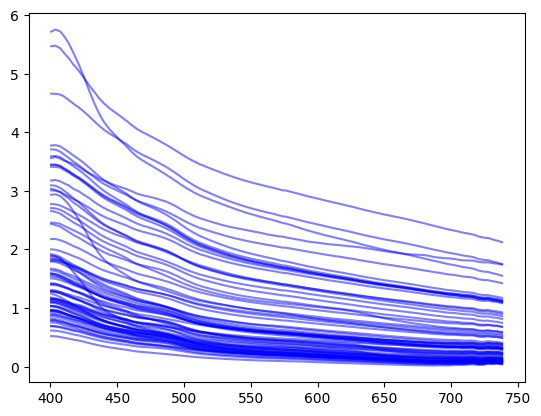

In [5]:
import matplotlib.pyplot as plt

sp_cols_a = spectra_A_df.columns[23:]
wav_A = np.array(sp_cols_a.astype("float"))


for (i, sample_data) in spectra_A_df.iterrows():
    plt.plot(wav_A, sample_data[sp_cols_a], color="blue", alpha=0.5)

plt.show()

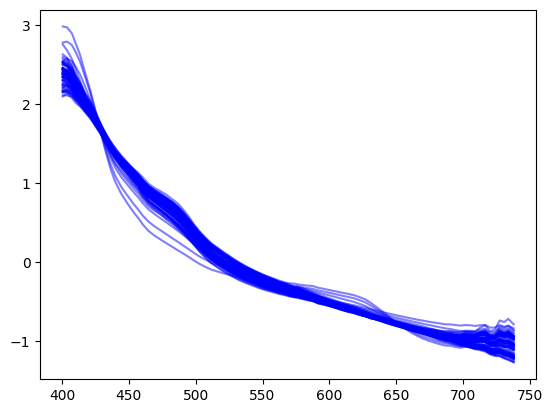

In [6]:
import matplotlib.pyplot as plt

sp_cols_a = spectra_A_df.columns[23:]
wav_A = np.array(sp_cols_a.astype("float"))


for (i, sample_data) in spectra_A_df.iterrows():
    sp = sample_data[sp_cols_a] 
    snv_sp = ( sp - sp.mean() ) / sp.std()
    plt.plot(wav_A, snv_sp, color="blue", alpha=0.5)

plt.show()

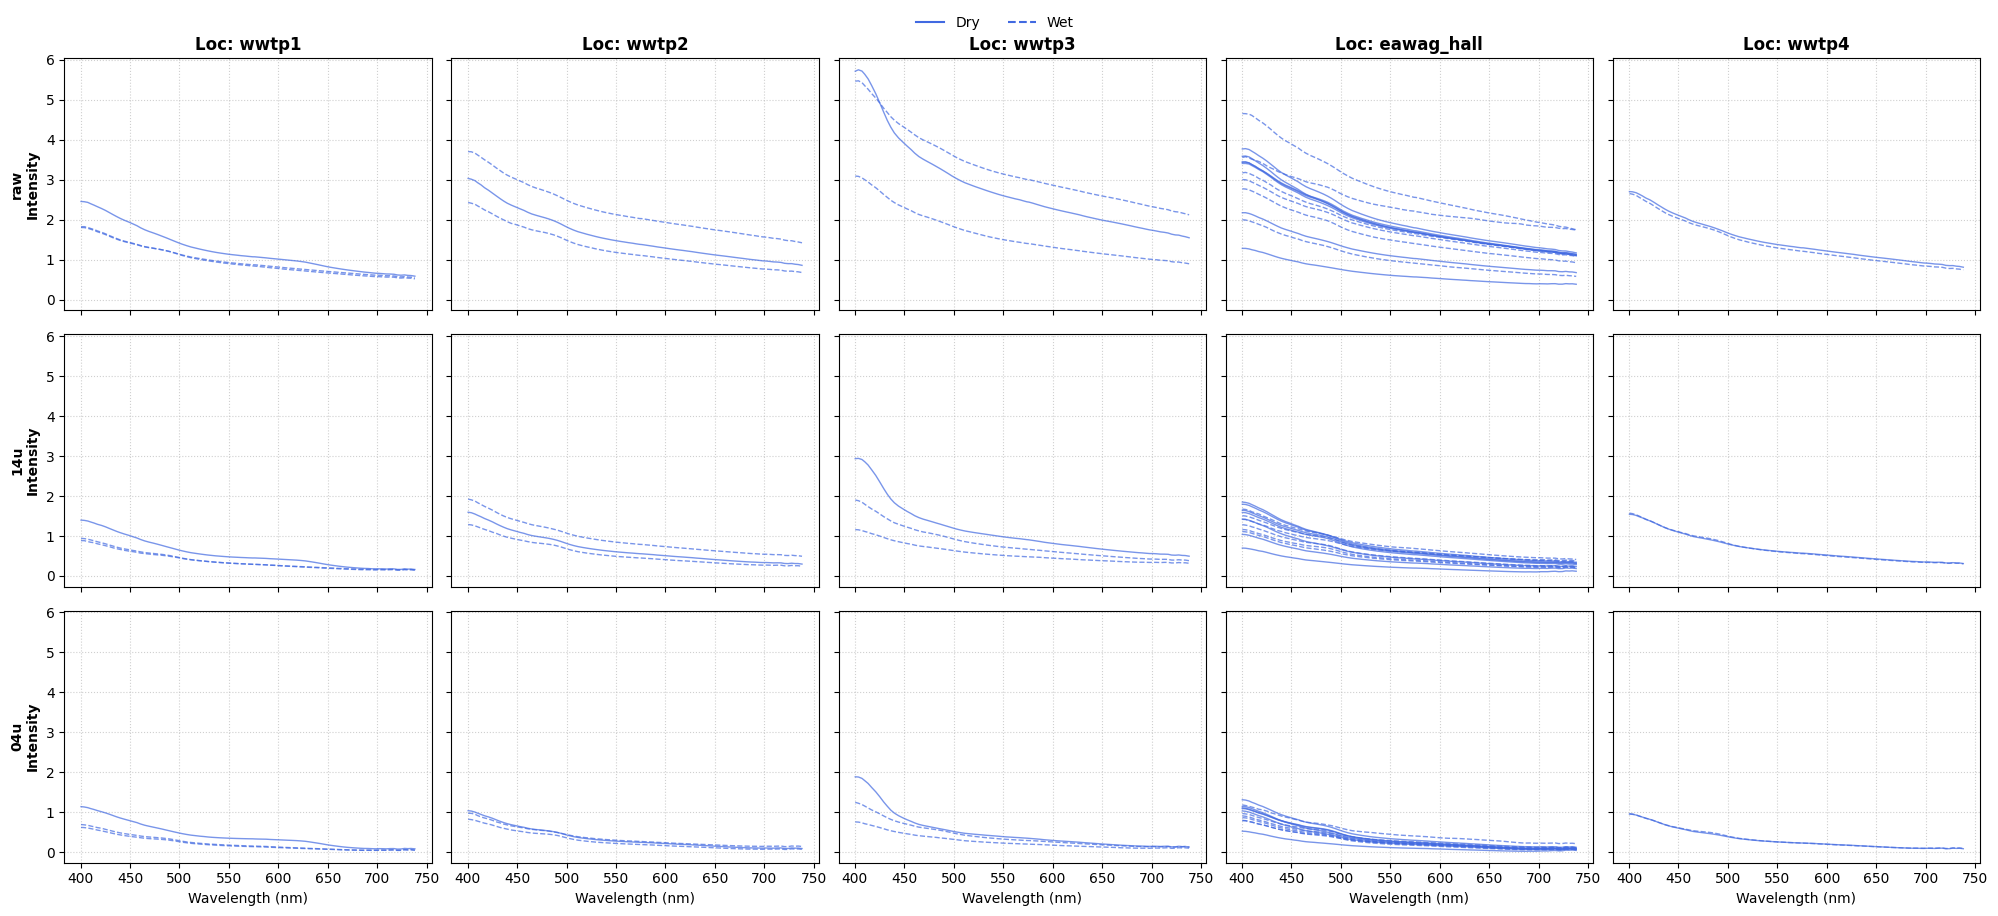

In [7]:
sp_cols_a = spectra_A_df.columns[23:]
wav_A = np.array(sp_cols_a.astype("float"))

# Get unique categories for the grid
prep_cats = spectra_A_df["preprocessing"].unique()
loc_cats = spectra_A_df["sampling_location"].unique()

n_rows = len(prep_cats)
n_cols = len(loc_cats)

# --- 3. Create the Figure Grid ---
fig, axes = plt.subplots(n_rows, n_cols, 
                         figsize=(4 * n_cols, 3 * n_rows), 
                         sharex=True, sharey=True)

# Ensure axes is a 2D array even if there is only 1 row or 1 column
if n_rows == 1: axes = np.expand_dims(axes, axis=0)
if n_cols == 1: axes = np.expand_dims(axes, axis=1)

# --- 4. Nested Loop to fill the grid ---
for r, prep in enumerate(prep_cats):
    for c, loc in enumerate(loc_cats):
        ax = axes[r, c]
        ax.grid(True, linestyle=':', alpha=0.6)
        
        # Filter data for this specific cell (Prep method + Location)
        mask = (spectra_A_df["preprocessing"] == prep) & \
               (spectra_A_df["sampling_location"] == loc)
        subset = spectra_A_df[mask]
        
        if not subset.empty:
            # Split subset by weather to apply different line styles
            # Dry = Solid line (-), Wet = Dashed line (--)
            for condition, style in [("dry", "-"), ("wet", "--")]:
                weather_subset = subset[subset["weather"] == condition]
                
                if not weather_subset.empty:
                    # Plotting the transposed data (all lines for this category at once)
                    ax.plot(wav_A, weather_subset[sp_cols_a].T, 
                            color="royalblue", 
                            linestyle=style, 
                            linewidth=1,
                            alpha=0.7)
        
        # Formatting titles and labels
        if r == 0:
            ax.set_title(f"Loc: {loc}", fontweight='bold', fontsize=12)
        if c == 0:
            ax.set_ylabel(f"{prep}\nIntensity", fontweight='bold', fontsize=10)
        if r == n_rows - 1:
            ax.set_xlabel("Wavelength (nm)")

# --- 5. Global Legend & Final Touches ---
# Create custom lines for a single clear legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='royalblue', linestyle='-', label='Dry'),
    Line2D([0], [0], color='royalblue', linestyle='--', label='Wet')
]
fig.legend(handles=legend_elements, loc='upper center', 
           bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False)

plt.tight_layout()
plt.show()

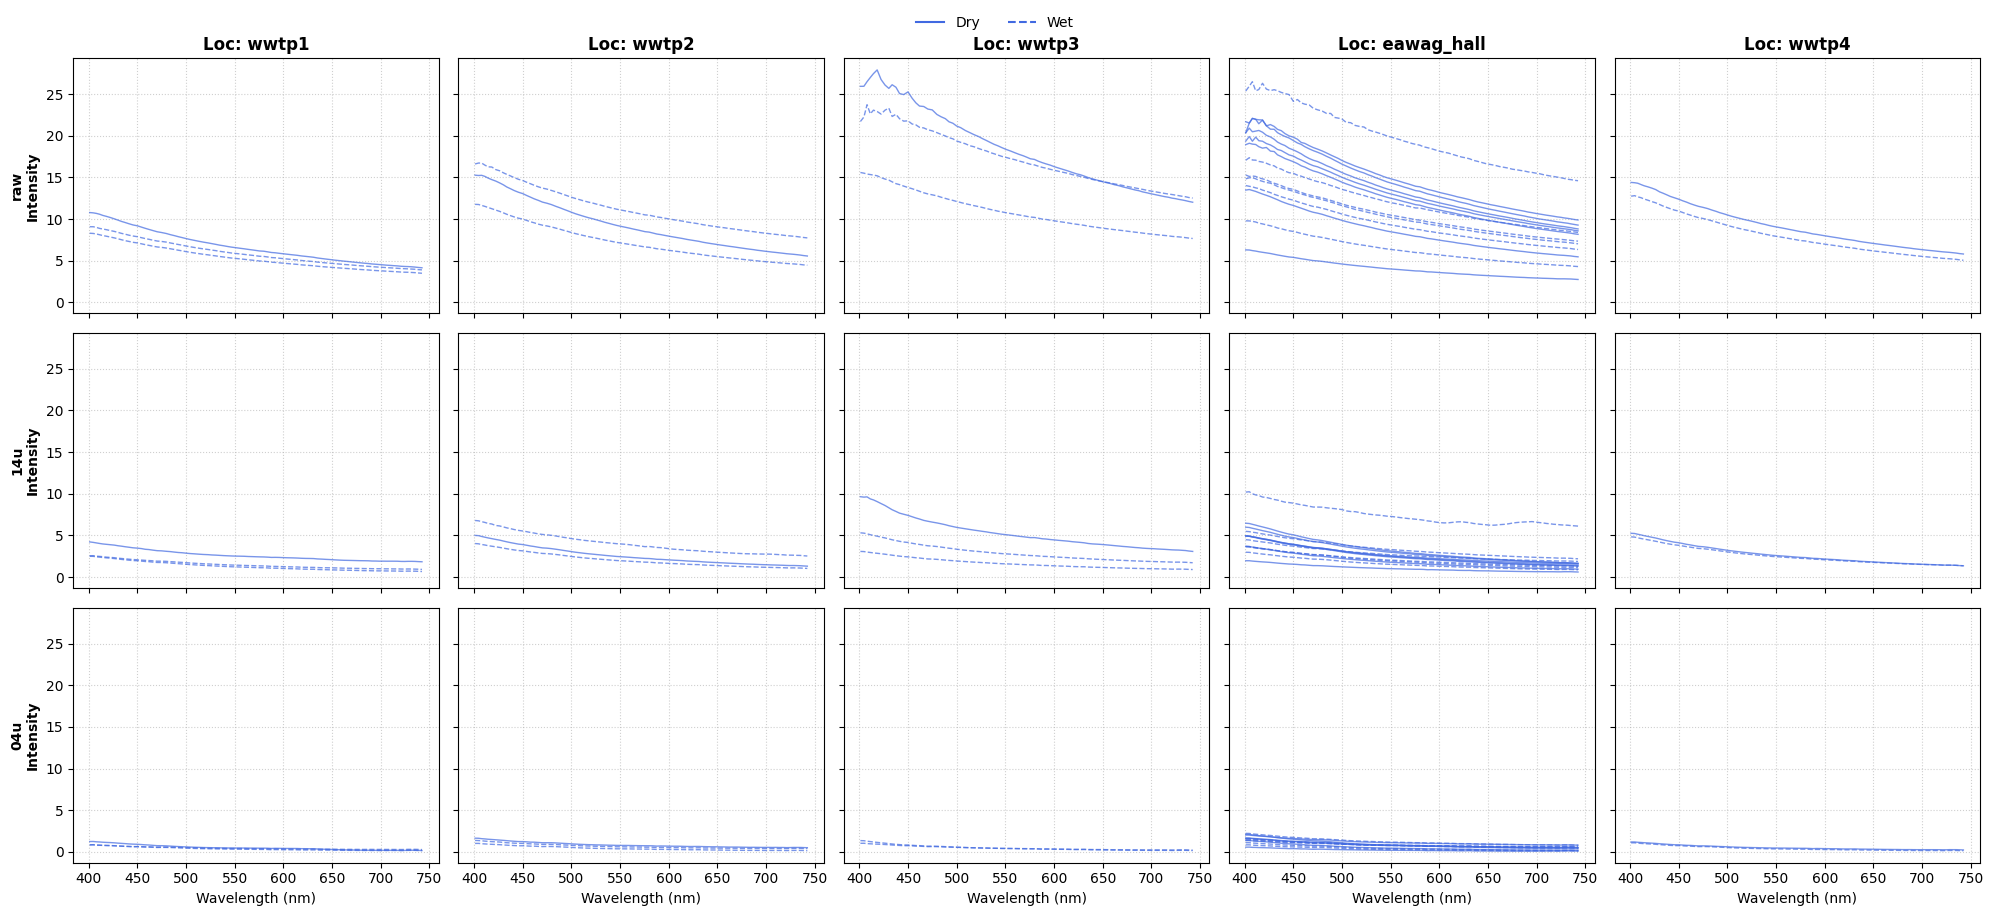

In [8]:
spectra_S_df = lab_data.merge(spectra_S_df)

sp_cols_S = spectra_S_df.columns[23:]
wav_S = np.array(sp_cols_S.astype("float"))

# Get unique categories for the grid
prep_cats = spectra_S_df["preprocessing"].unique()
loc_cats = spectra_S_df["sampling_location"].unique()

n_rows = len(prep_cats)
n_cols = len(loc_cats)

# --- 3. Create the Figure Grid ---
fig, axes = plt.subplots(n_rows, n_cols, 
                         figsize=(4 * n_cols, 3 * n_rows), 
                         sharex=True, sharey=True)

# Ensure axes is a 2D array even if there is only 1 row or 1 column
if n_rows == 1: 
    axes = np.expand_dims(axes, axis=0)
if n_cols == 1: 
    axes = np.expand_dims(axes, axis=1)

# --- 4. Nested Loop to fill the grid ---
for r, prep in enumerate(prep_cats):
    for c, loc in enumerate(loc_cats):
        ax = axes[r, c]
        ax.grid(True, linestyle=':', alpha=0.6)
        
        # Filter data for this specific cell (Prep method + Location)
        mask = (spectra_S_df["preprocessing"] == prep) & \
               (spectra_S_df["sampling_location"] == loc)
        subset = spectra_S_df[mask]
        
        if not subset.empty:
            # Split subset by weather to apply different line styles
            # Dry = Solid line (-), Wet = Dashed line (--)
            for condition, style in [("dry", "-"), ("wet", "--")]:
                weather_subset = subset[subset["weather"] == condition]
                
                if not weather_subset.empty:
                    # Plotting the transposed data (all lines for this category at once)
                    ax.plot(wav_S, weather_subset[sp_cols_S].T, 
                            color="royalblue", 
                            linestyle=style, 
                            linewidth=1,
                            alpha=0.7)
        
        # Formatting titles and labels
        if r == 0:
            ax.set_title(f"Loc: {loc}", fontweight='bold', fontsize=12)
        if c == 0:
            ax.set_ylabel(f"{prep}\nIntensity", fontweight='bold', fontsize=10)
        if r == n_rows - 1:
            ax.set_xlabel("Wavelength (nm)")

# --- 5. Global Legend & Final Touches ---
# Create custom lines for a single clear legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='royalblue', linestyle='-', label='Dry'),
    Line2D([0], [0], color='royalblue', linestyle='--', label='Wet')
]
fig.legend(handles=legend_elements, loc='upper center', 
           bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False)

plt.tight_layout()
plt.show()

We see dilution effect but not that much the first flush. Would need to monitor rain events in higher resolution. 

# Scattering coeff power law fit and how it relates to turbidity

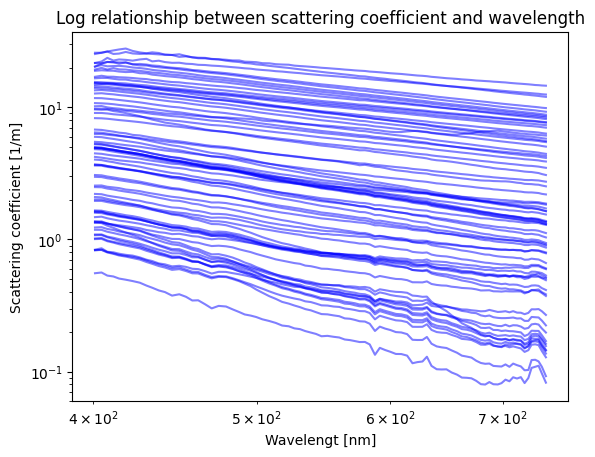

In [15]:
for (i, sample_data) in spectra_S_df.iterrows():
    plt.plot(wav_S, sample_data[sp_cols_S], color="blue", alpha=0.5)

plt.xscale("log"), 
plt.yscale("log")
plt.ylabel("Scattering coefficient [1/m]")
plt.xlabel("Wavelengt [nm]")
plt.title("Log relationship between scattering coefficient and wavelength")
plt.show()

In [10]:
def get_turbidity(full_sample_name, lab_data):
    # 1. Determine which column to look at based on the suffix
    if "raw" in full_sample_name:
        col = "tur_raw_ntu"
    elif "04u" in full_sample_name:
        col = "tur_04u_ntu"
    elif "14u" in full_sample_name:
        col = "tur_14u_ntu"
    else:
        return None # Or handle cases that don't match
    
    # 2. Extract the ID (first 3 chars, e.g., 's01')
    sample_id = full_sample_name[:3]
    
    # 3. Filter the lab_data for the row where 'sample_name' matches the ID
    # and select the specific column 'col'
    try:
        match = lab_data[lab_data["sample"] == sample_id]
        return match[col].values[0]
    except (IndexError, KeyError):
        return None

# Test call
# Ensure lab_data has 'sample_name' like 's01' and 'tur_raw_ntu'
# result = get_turbidity("s01_raw", lab_data)
    
print(get_turbidity("s01_raw", lab_data))

3.55


<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
C:\Users\pierr\AppData\Local\Temp\ipykernel_22064\518005232.py:34: SyntaxWarning: invalid escape sequence '\l'
  ax[0].set_ylabel('Intercept ($\log a$)')


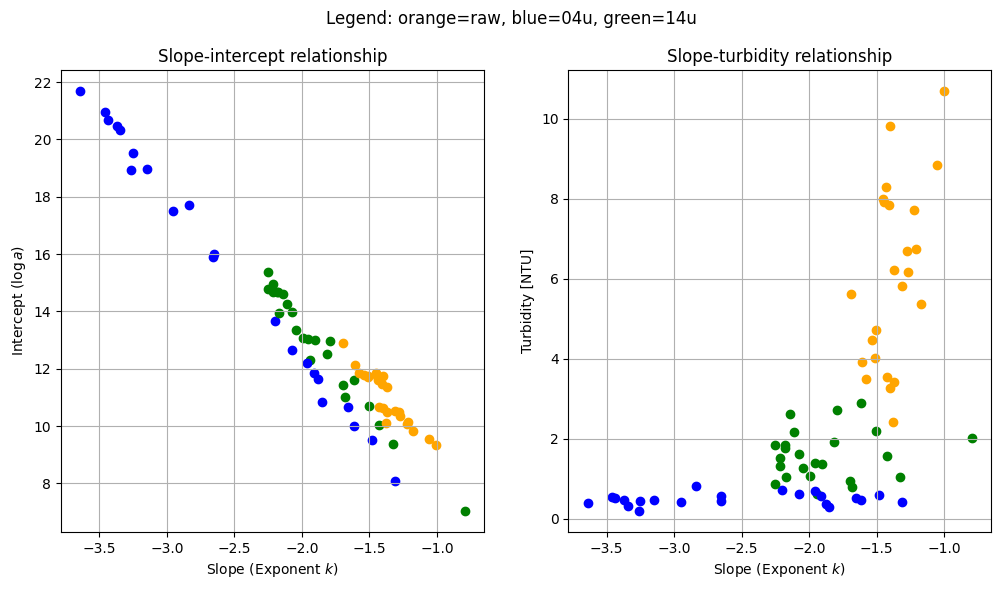

In [11]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 6))

color_map = {
    "raw": "orange", 
    "04u": "blue", 
    "14u": "green" 
}

for (i, sample_data) in spectra_S_df.iterrows():
    try:
        full_sample_name = sample_data["full_sample_name"]
        
        if "raw" in full_sample_name:
            color = color_map['raw']
            label="raw"
        elif "04u" in full_sample_name:
            color = color_map['04u']
            label="04u"
        elif "14u" in full_sample_name:
            color = color_map['14u']
            label="14u"

        
        y_values = sample_data[sp_cols_S].values.astype(float)
        slope, intercept = np.polyfit(np.log(wav_S), np.log(y_values), 1)
        turbidity = get_turbidity(full_sample_name=full_sample_name, lab_data=lab_data)
        ax[0].scatter(slope, intercept, color=color, label=label)
        ax[1].scatter(slope, turbidity, color=color, label=label)
    except Exception as e:
        print(f"ERROR TYPE: {type(e).__name__}")
        print(f"ERROR MESSAGE: {e}")
    
ax[0].set_xlabel('Slope (Exponent $k$)')
ax[0].set_ylabel('Intercept ($\log a$)')
ax[0].set_title('Slope-intercept relationship')
ax[0].grid(True)
ax[1].set_xlabel('Slope (Exponent $k$)')
ax[1].set_ylabel('Turbidity [NTU]')
ax[1].set_title('Slope-turbidity relationship')
ax[1].grid(True)

fig.suptitle("Legend: orange=raw, blue=04u, green=14u")

plt.show()


# PCA of SNV processed spectra, looking at PC1 and PC2 as a function of the plant

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Isolate spectral data from metadata
# Use columns from 23 onwards as features
X = spectra_A_df.iloc[:, 23:].values
y = spectra_A_df['sampling_location']

# 2. SNV Preprocessing: Focuses on "Shape" 
# Formula: (x - mean(x)) / std(x) for each individual spectrum
X_snv = (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True)

# 3. Standard Scaling (across features)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_snv)

# 4. Perform PCA
pca = PCA(n_components=5)
pca_result = pca.fit_transform(X_scaled)

# Create result dataframe for plotting
pca_df = pd.DataFrame(data=pca_result, columns=[f'PC{i+1}' for i in range(5)])
pca_df['sampling_location'] = y.values

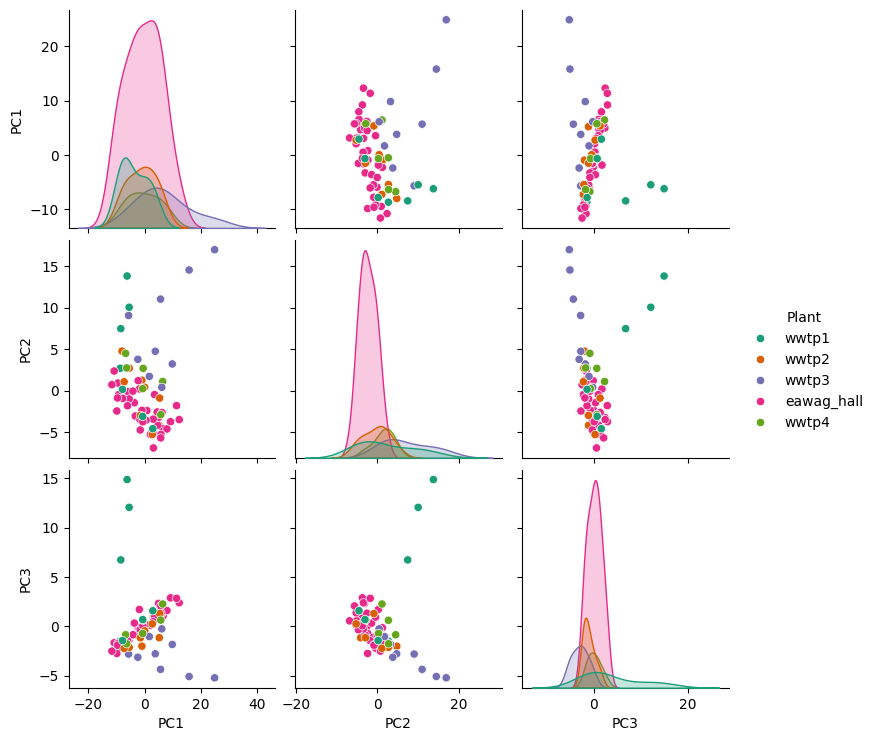

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Isolate spectral data based on your specific dataframe structure
# Columns 23 onwards are your wavelengths
X = spectra_A_df.iloc[:, 23:].values
y = spectra_A_df['sampling_location']

# 2. Preprocessing: Standard Normal Variate (SNV)
# This centers and scales each row independently to focus purely on spectral shape.
X_snv = (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True)

# 3. Standardization (Scaling across features)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_snv)

# Create a DF with the first 4 or 5 PCs
pca_full = PCA(n_components=4)
X_pca_full = pca_full.fit_transform(X_scaled)
pca_df_full = pd.DataFrame(X_pca_full, columns=[f'PC{i+1}' for i in range(4)])
pca_df_full['Plant'] = y.values

# Generate a pairplot for the first 4 PCs
sns.pairplot(pca_df_full, vars=['PC1', 'PC2', 'PC3'], hue='Plant', palette='Dark2', diag_kind='kde')
plt.show()

In [14]:

import plotly.express as px


# 1. Use the PCA results you already calculated (X_pca_full)
# We will create a clean dataframe for the interactive plot
df_3d = pd.DataFrame(X_pca_full[:, :3], columns=['PC1', 'PC2', 'PC3'])
df_3d['Plant'] = y.values

# 2. Create the 3D Scatter Plot
fig = px.scatter_3d(
    df_3d, 
    x='PC1', 
    y='PC2', 
    z='PC3',
    color='Plant',
    symbol='Plant', # Different shapes for different plants
    opacity=0.7,
    title='Interactive 3D PCA: Wastewater Spectra Comparison',
    labels={
        'PC1': f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)',
        'PC2': f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)',
        'PC3': f'PC3 ({pca_full.explained_variance_ratio_[2]*100:.1f}%)'
    }
)

# 3. Enhance the layout
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=40),
    legend=dict(yanchor="top", y=0.9, xanchor="left", x=0.1)
)

# Show the plot
fig.show()